# 心脏病预测机器学习项目

## 一、数据预处理

### 1.1 数据集探索与统计分析

In [121]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取数据集
df = pd.read_csv('heart.csv')

In [122]:
# 查看数据集基本信息
print("数据集形状:", df.shape)
print("\n数据集前5行:")
print(df.head())
print("\n数据集基本信息:")
print(df.info())
print("\n数据集统计描述:")
print(df.describe())

# 查看每个特征的唯一值数量
print("\n每个特征的唯一值数量:")
print(df.nunique())

数据集形状: (918, 12)

数据集前5行:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

数据集基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
Age               918 non-null int64
Sex               918 non-nul

数据集特征说明
- **Age**: 年龄
- **Sex**: 性别（M=男性；F=女性）
- **ChestPain**: 胸痛类型
  - ATA: 典型心绞痛
  - NAP: 非典型心绞痛
  - ASY: 无症状
- **RestingBP**: 静息血压（mmHg）
- **Cholester**: 血清胆固醇（mg/dl）
- **FastingBS**: 空腹血糖（0=正常；1=异常）
- **RestingECG**: 静息心电图结果
  - Normal: 正常
  - ST: ST-T波异常
- **MaxHR**: 最大心率（每分钟跳动次数）
- **Exercise**: 运动诱发心绞痛（Y=是；N=否）
- **Oldpeak**: ST段压低（运动相对于休息时的变化）
- **ST_Slope**: 心电图ST段的斜率
  - Up: 上升
  - Flat: 平坦
- **HeartDisease**: 是否患有心脏病（0=否；1=是）

### 1.2 处理缺失值和异常值

In [123]:
# 检查缺失值
print("缺失值统计:")
print(df.isnull().sum())

# 选择数值型特征
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

# 选择需要检查的数值型特征
features_to_check = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# 查看数据分布
print("各特征的取值范围：")
for feature in features_to_check:
    print(f"\n{feature}:")
    print(f"最小值: {df[feature].min()}")
    print(f"最大值: {df[feature].max()}")

缺失值统计:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
各特征的取值范围：

Age:
最小值: 28
最大值: 77

RestingBP:
最小值: 0
最大值: 200

Cholesterol:
最小值: 0
最大值: 603

MaxHR:
最小值: 60
最大值: 202

Oldpeak:
最小值: -2.6
最大值: 6.2


医学人体所能达到的指标：
|指标|极限数值范围|
| ---- | ---- |
|Age（年龄）|0-120岁|
|RestingBP（静息血压）|≥90mmHg（下限），可达370mmHg左右（上限极罕见情况）|
|Cholesterol（胆固醇）|≥100mg/dl（下限），暂无明确上限数值|
|MaxHR（最大心率）|≥60bpm（下限），可短暂超过220 - 年龄（上限难确定确切值）|
|Oldpeak（ST段压低）|≥0（下限），暂无明确上限数值，超过0.2mV提示较严重情况| 

根据医学人体所能达到的指标，我们仅需处理不符合生理范围的数据如Cholesterol、Oldpeak即可

In [124]:
# 处理前打印异常值的具体情况
print("处理前的异常值情况：")

# 1. 检查胆固醇低于100的情况
chol_abnormal = df[df['Cholesterol'] < 100]
print(f"胆固醇低于100的记录数: {len(chol_abnormal)}")
if len(chol_abnormal) > 0:
    print("异常值:", chol_abnormal['Cholesterol'].values)

# 2. 检查ST段压低为负值的情况
oldpeak_abnormal = df[df['Oldpeak'] < 0]
print("\nST段压低为负值的记录数:", len(oldpeak_abnormal))
if len(oldpeak_abnormal) > 0:
    print("异常值:", oldpeak_abnormal['Oldpeak'].values)

# 处理异常值
df_cleaned = df.copy()

# 1. 处理胆固醇异常值（小于100的设为100）
df_cleaned.loc[df_cleaned['Cholesterol'] < 100, 'Cholesterol'] = 100

# 2. 处理ST段压低的负值（设为0）
df_cleaned.loc[df_cleaned['Oldpeak'] < 0, 'Oldpeak'] = 0

# 打印处理后的范围
print("\n处理后的取值范围：")
for feature in ['Cholesterol', 'Oldpeak']:
    print(f"{feature}:")
    print(f"最小值: {df_cleaned[feature].min():.3f}")
    print(f"最大值: {df_cleaned[feature].max():.3f}")

# 更新数据集
df = df_cleaned.copy()

处理前的异常值情况：
胆固醇低于100的记录数: 173
异常值: [85  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0]

ST段压低为负值的记录数: 13
异常值: [-0.9 -2.6 -1.5 -0.1 -1.  -1.1 -0.7 -0.8 -1.  -0.5 -2.  -0.5 -0.1]

处理后的取值范围：
Cholesterol:
最小值: 100.000
最大值: 603.000
Oldpeak:
最小值: 0.000
最大值: 6.200


### 1.3 数据可视化分析

#### 1.3.1 特征分布直方图

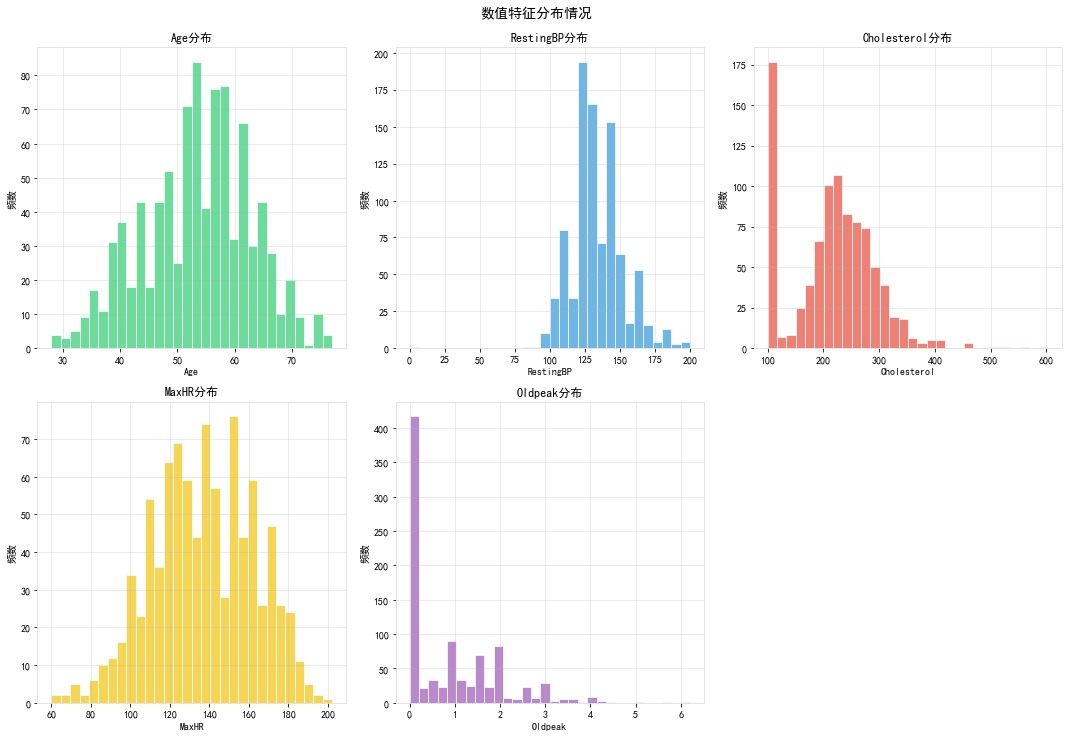


=== 特征统计信息 ===

Age特征统计量:
最小值: 28.00
最大值: 77.00
均值: 53.51
中位数: 54.00
标准差: 9.43

RestingBP特征统计量:
最小值: 0.00
最大值: 200.00
均值: 132.40
中位数: 130.00
标准差: 18.51

Cholesterol特征统计量:
最小值: 100.00
最大值: 603.00
均值: 217.55
中位数: 223.00
标准差: 77.64

MaxHR特征统计量:
最小值: 60.00
最大值: 202.00
均值: 136.81
中位数: 138.00
标准差: 25.46

Oldpeak特征统计量:
最小值: 0.00
最大值: 6.20
均值: 0.90
中位数: 0.60
标准差: 1.05


In [125]:
# 绘制数值型特征的分布直方图
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f1c40f', '#9b59b6']

# 使用enumerate和zip同时遍历特征列表和颜色列表
# enumerate提供索引idx和元组(feature, color)
# zip将numeric_features和colors打包成元组对
# idx用于选择子图位置
# feature是特征名称
# color是对应的颜色值
for idx, (feature, color) in enumerate(zip(numeric_features, colors)):
    # 计算直方图数据
    axes[idx].hist(df[feature], bins=30, edgecolor='white', 
                  color=color, alpha=0.7)
    
    # 美化标题和标签
    axes[idx].set_title(f'{feature}分布', fontsize=12)  # Removed pad parameter
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('频数', fontsize=10)
    
    # 设置网格
    axes[idx].grid(True, alpha=0.3)
    
    # 美化边框
    for spine in axes[idx].spines.values():
        spine.set_edgecolor('#dcdde1')

# 移除多余的子图
if len(numeric_features) < len(axes):
    axes[-1].remove()

# 调整布局
plt.suptitle('数值特征分布情况', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 分析每个特征的分布情况
print("\n=== 特征统计信息 ===")
for feature in numeric_features:
    print(f"\n{feature}特征统计量:")
    stats = df[feature].describe()
    print(f"最小值: {stats['min']:.2f}")
    print(f"最大值: {stats['max']:.2f}")
    print(f"均值: {stats['mean']:.2f}")
    print(f"中位数: {stats['50%']:.2f}")
    print(f"标准差: {stats['std']:.2f}")


**数值特征分布分析**

* `Age`(年龄)：
  - 呈现近似正态分布
  - 分布较为集中

* `RestingBP`(静息血压)：
  - 呈现双峰分布
  - 分布较为分散

* `Cholesterol`(胆固醇)：
  - 主体分布在150到350之间

* `MaxHR`(最大心率)：
  - 近似正态分布
  - 分布较为均匀

* `Oldpeak`(ST段压低)：
  - 呈现长尾分布
  - 数据分布不均匀

### 1.3.2 特征相关性分析

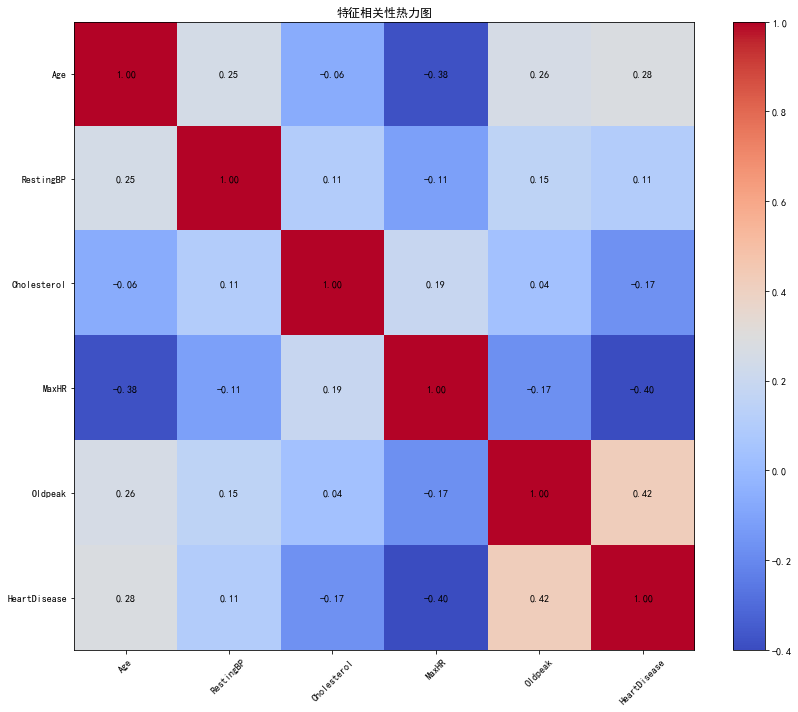


重要特征相关性：

与心脏病的相关性：
HeartDisease    1.000000
Oldpeak         0.420466
Age             0.282039
RestingBP       0.107589
Cholesterol    -0.167699
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


In [126]:
# 计算相关性矩阵，排除二分类变量FastingBS
numeric_columns = [col for col in df.columns if col != 'FastingBS']
correlation_matrix = df[numeric_columns].corr()

# 绘制相关性热力图
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()

# 添加相关系数标签
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                ha='center', va='center')

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('特征相关性热力图')
plt.tight_layout()
plt.show()

# 输出相关性
print("\n重要特征相关性：")
# 获取与目标变量(HeartDisease)的相关性
target_correlations = correlation_matrix['HeartDisease'].sort_values(ascending=False)
print("\n与心脏病的相关性：")
print(target_correlations)

相关性分析结论

- 强相关特征
    * `Oldpeak`(+0.42): ST段压低越大，患病风险越高
    * `MaxHR`(-0.40): 最大心率越低，患病风险越高

- 中等相关特征
    * `Age`(+0.28): 年龄越大，患病风险略增
    

- 弱相关特征
    
    * `Cholesterol`(-0.17): 与胆固醇呈弱负相关
    * `RestingBP`(+0.11): 与静息血压几乎无关

**结论**: 建模时可以重点关注`Oldpeak`和`MaxHR`这两个特征。

#### 1.3.3 心率与年龄的散点图

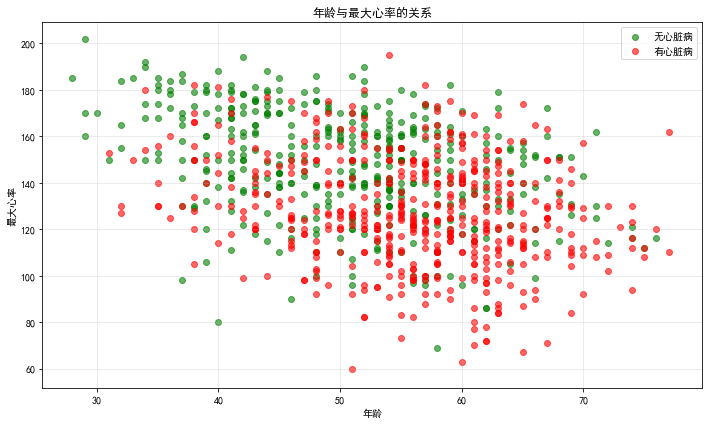

In [127]:
plt.figure(figsize=(10, 6))
colors = ['green', 'red']
for i, status in enumerate(['无心脏病', '有心脏病']):
    mask = df['HeartDisease'] == i
    plt.scatter(df[mask]['Age'], df[mask]['MaxHR'], 
                c=colors[i], label=status, alpha=0.6)
plt.title('年龄与最大心率的关系', fontsize=12)
plt.xlabel('年龄', fontsize=10)
plt.ylabel('最大心率', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1.随着年龄增长，最大心率呈现明显的下降趋势

2.心脏病患者（红点）的最大心率普遍低于同龄健康人群（绿点），尤其在50岁以上人群中这种差异更为明显

#### 1.3.4 心脏病患者年龄分布对比图

c:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:52: FutureWarning: reshape is deprecated and will raise in a subsequent release. Please use .values.reshape(...) instead
  return getattr(obj, method)(*args, **kwds)


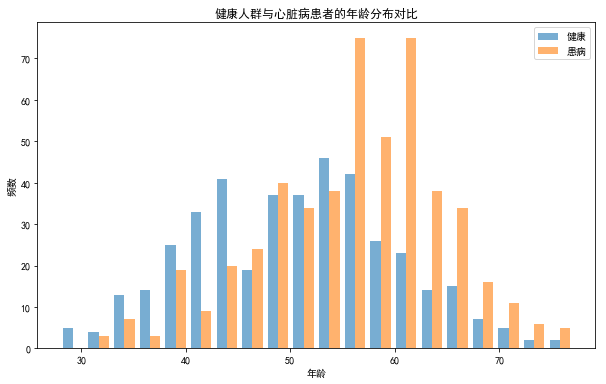

In [128]:
plt.figure(figsize=(10, 6))
plt.hist([df[df['HeartDisease']==0]['Age'], 
          df[df['HeartDisease']==1]['Age']], 
         label=['健康', '患病'],
         bins=20, alpha=0.6)
plt.title('健康人群与心脏病患者的年龄分布对比')
plt.xlabel('年龄')
plt.ylabel('频数')
plt.legend()
plt.show()

1.心脏病患者主要集中在55-65岁年龄段，这个区间的患病人数明显高于健康人数

2.40岁以下人群中健康人数较多，说明心脏病是一种与年龄正相关的疾病

#### 1.3.5 不同胸痛类型的心脏病比例堆叠图

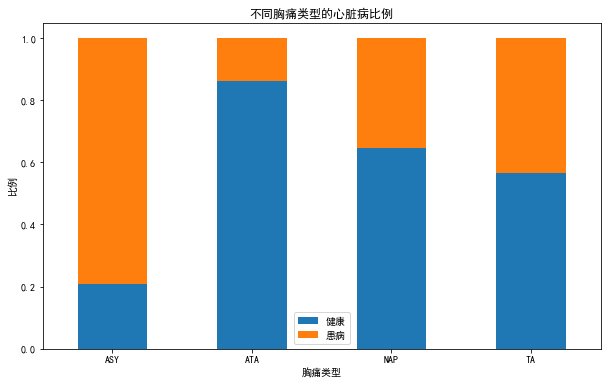

In [129]:
# 计算不同胸痛类型中心脏病的比例
pain_disease = pd.crosstab(df['ChestPainType'], df['HeartDisease'], normalize='index')
pain_disease.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('不同胸痛类型的心脏病比例')
plt.xlabel('胸痛类型')
plt.ylabel('比例')
plt.legend(['健康', '患病'])
plt.xticks(rotation=0)
plt.show()

1. **典型心绞痛(ATA)患者中约85%是健康的**，显示典型心绞痛可能不是心脏病的主要指征。

2. **无症状(ASY)和非典型心绞痛(NAP)的患者中**，有心脏病的比例明显更高，这提示不典型症状反而需要更多关注。

## 二、特征工程

### 2.1 特征选择

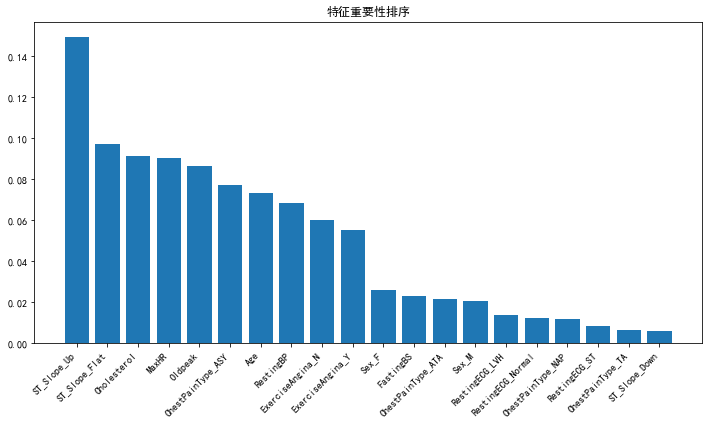

选择的重要特征：
['ST_Slope_Up', 'ST_Slope_Flat', 'Cholesterol', 'MaxHR', 'Oldpeak', 'ChestPainType_ASY', 'Age', 'RestingBP', 'ExerciseAngina_N', 'ExerciseAngina_Y']


In [130]:
# 1. 分离数值特征和类别特征
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# 2. 使用随机森林评估特征重要性
# 对类别特征进行独热编码
X = pd.get_dummies(df[numeric_features + categorical_features])
y = df['HeartDisease']

# 训练随机森林
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 获取特征重要性
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# 可视化特征重要性
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)), feature_importance['importance'])
plt.xticks(range(len(feature_importance)), feature_importance['feature'], rotation=45, ha='right')
plt.title('特征重要性排序')
plt.tight_layout()
plt.show()

# 选择重要性大于平均值的特征
important_features = feature_importance[
    feature_importance['importance'] > feature_importance['importance'].mean()
]['feature'].tolist()

print("选择的重要特征：")
print(important_features)

### 2.2 特征缩放

In [131]:
# 1. 对数值特征进行标准化
scaler = StandardScaler()
X_numeric = df[numeric_features]
X_numeric_scaled = scaler.fit_transform(X_numeric)

# 将标准化后的数据转换回DataFrame
X_numeric_scaled = pd.DataFrame(
    X_numeric_scaled, 
    columns=numeric_features,
    index=df.index
)

# 2. 对类别特征进行独热编码
X_categorical = pd.get_dummies(df[categorical_features])

# 3. 合并处理后的特征
X_processed = pd.concat([X_numeric_scaled, X_categorical], axis=1)

# 查看处理后的数据
print("\n处理后的特征形状:", X_processed.shape)
print("\n处理后的特征列表:", X_processed.columns.tolist())


处理后的特征形状: (918, 20)

处理后的特征列表: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


### 2.3 特征编码

In [132]:
# 1. 对类别特征进行标签编码
X_encoded = df.copy()

# 对每个类别特征进行标签编码
label_encoders = {}
for feature in categorical_features:
    label_encoders[feature] = LabelEncoder()
    X_encoded[feature] = label_encoders[feature].fit_transform(df[feature])

# 2. 对类别特征进行独热编码
X_onehot = pd.get_dummies(df[categorical_features])  # 移除prefix_dict，直接使用默认前缀

# 3. 创建最终的特征矩阵
X_final = pd.concat([X_numeric_scaled, X_onehot], axis=1)

# 打印编码结果
print("=== 特征编码结果 ===")
print("\n1. 标签编码示例（前5行）:")
print(X_encoded[categorical_features].head())

print("\n2. 独热编码后的特征数量:", X_onehot.shape[1])
print("\n3. 最终特征矩阵形状:", X_final.shape)

# 4. 查看编码映射关系
print("\n=== 类别特征编码映射关系 ===")
for feature in categorical_features:
    unique_values = df[feature].unique()
    encoded_values = label_encoders[feature].transform(unique_values)
    mapping = dict(zip(unique_values, encoded_values))
    print(f"\n{feature}特征编码映射:")
    for original, encoded in mapping.items():
        print(f"{original} -> {encoded}")

=== 特征编码结果 ===

1. 标签编码示例（前5行）:
   Sex  ChestPainType  FastingBS  RestingECG  ExerciseAngina  ST_Slope
0    1              1          0           1               0         2
1    0              2          0           1               0         1
2    1              1          0           2               0         2
3    0              0          0           1               1         1
4    1              2          0           1               0         2

2. 独热编码后的特征数量: 15

3. 最终特征矩阵形状: (918, 20)

=== 类别特征编码映射关系 ===

Sex特征编码映射:
M -> 1
F -> 0

ChestPainType特征编码映射:
ATA -> 1
NAP -> 2
ASY -> 0
TA -> 3

FastingBS特征编码映射:
0 -> 0
1 -> 1

RestingECG特征编码映射:
Normal -> 1
ST -> 2
LVH -> 0

ExerciseAngina特征编码映射:
N -> 0
Y -> 1

ST_Slope特征编码映射:
Up -> 2
Flat -> 1
Down -> 0


## 三、模型构建与训练

### 3.1 数据集划分

In [133]:
# 1. 准备特征和标签
X = X_final  # 使用特征工程后的特征矩阵
y = df['HeartDisease']  # 目标变量

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     
    random_state=42,   
    stratify=y         # 保持标签比例一致
)

# 3. 打印数据集形状
print("=== 数据集划分结果 ===")
print(f"训练集特征形状: {X_train.shape}")
print(f"测试集特征形状: {X_test.shape}")
print(f"训练集标签形状: {y_train.shape}")
print(f"测试集标签形状: {y_test.shape}")

# 4. 检查类别分布
print("\n=== 类别分布 ===")
print("训练集类别分布:")
print(y_train.value_counts(normalize=True))
print("\n测试集类别分布:")
print(y_test.value_counts(normalize=True))

=== 数据集划分结果 ===
训练集特征形状: (734, 20)
测试集特征形状: (184, 20)
训练集标签形状: (734,)
测试集标签形状: (184,)

=== 类别分布 ===
训练集类别分布:
1    0.553134
0    0.446866
Name: HeartDisease, dtype: float64

测试集类别分布:
1    0.554348
0    0.445652
Name: HeartDisease, dtype: float64


### 3.2 基础模型训练

In [134]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

# 训练和评估模型
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# 存储结果
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = evaluate_model(model, X_test, y_test)

# 创建性能比较表格
df_results = pd.DataFrame(results).round(4).T
df_results.columns = ['准确率%', '精确率%', '召回率%', 'F1分数%']

print("\n=== 模型性能比较===")
print(df_results)

# 找出每个指标的最佳模型
best_models = df_results.idxmax()
print("\n=== 最佳表现模型 ===")
for metric, model in best_models.items():
    print(f"{metric}: {model} ({df_results.loc[model, metric]:.4f})")


=== 模型性能比较===
                       准确率%    精确率%    召回率%   F1分数%
KNN                  0.8967  0.9064  0.9109  0.9020
Logistic Regression  0.8913  0.9048  0.8796  0.9314
Random Forest        0.9076  0.9187  0.8972  0.9412
SVM                  0.8696  0.8835  0.8750  0.8922

=== 最佳表现模型 ===
准确率%: Random Forest (0.9076)
精确率%: Random Forest (0.9187)
召回率%: KNN (0.9109)
F1分数%: Random Forest (0.9412)


#### 3.2.2 损失函数与优化器

## 四、模型优化

### 4.1 参数调优

In [135]:
def perform_grid_search(model, param_grid, X, y, cv=5):
    """执行网格搜索"""
    grid_search = GridSearchCV(
        model, param_grid, cv=cv, 
        scoring='f1', n_jobs=-1, verbose=0
    )
    grid_search.fit(X, y)
    return grid_search.best_params_, grid_search.best_score_

#### 4.1.1 逻辑回归参数优化
# print("\n=== 逻辑回归参数优化 ===")
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}
lr_best_params, lr_best_score = perform_grid_search(
    LogisticRegression(random_state=42),
    lr_param_grid,
    X_train, y_train
)

#### 4.1.2 随机森林参数优化
# print("\n=== 随机森林参数优化 ===")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_best_params, rf_best_score = perform_grid_search(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    X_train, y_train
)

#### 4.1.3 支持向量机参数优化
# print("\n=== 支持向量机参数优化 ===")
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': [0.001, 0.01, 0.1, 1]  
}
svm_best_params, svm_best_score = perform_grid_search(
    SVC(random_state=42),
    svm_param_grid,
    X_train, y_train
)

#### 4.1.4 K近邻参数优化
# print("\n=== K近邻参数优化 ===")
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_best_params, knn_best_score = perform_grid_search(
    KNeighborsClassifier(),
    knn_param_grid,
    X_train, y_train
)

# 使用最佳参数训练模型
optimized_models = {
    'Logistic Regression': LogisticRegression(**lr_best_params, random_state=42),
    'Random Forest': RandomForestClassifier(**rf_best_params, random_state=42),
    'SVM': SVC(**svm_best_params, random_state=42),
    'KNN': KNeighborsClassifier(**knn_best_params)
}



### 4.2 交叉验证

In [136]:

print("\n=== 交叉验证结果 ===")
cv_results = {}

for name, model in optimized_models.items():
    # 执行5折交叉验证
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    cv_results[name] = {
        'mean_score': scores.mean(),
        'std_score': scores.std()
    }

# 最终模型评估
final_results = {}
for name, model in optimized_models.items():
    # 在完整训练集上训练
    model.fit(X_train, y_train)
    # 在测试集上评估
    y_pred = model.predict(X_test)
    final_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

# 创建最终结果表格
df_final = pd.DataFrame(final_results).round(4).T
df_final.columns = ['准确率', '精确率', '召回率', 'F1分数']

print("\n=== 优化后的模型性能比较（测试集）===")
print(df_final)

# 打印最佳参数
print("\n=== 最佳参数 ===")
best_params = {
    'Logistic Regression': lr_best_params,
    'Random Forest': rf_best_params,
    'SVM': svm_best_params,
    'KNN': knn_best_params
}

for model_name, params in best_params.items():
    print(f"\n{model_name}:")
    for param, value in params.items():
        print(f"{param}: {value}")

# 找出性能最好的模型
best_model = df_final['F1分数'].idxmax()
print(f"\n最佳模型: {best_model}")
print(f"F1分数: {df_final.loc[best_model, 'F1分数']:.4f}")


=== 交叉验证结果 ===

=== 优化后的模型性能比较（测试集）===
                        准确率     精确率     召回率    F1分数
KNN                  0.9185  0.9275  0.9143  0.9412
Logistic Regression  0.8913  0.9048  0.8796  0.9314
Random Forest        0.8967  0.9100  0.8807  0.9412
SVM                  0.8967  0.9082  0.8952  0.9216

=== 最佳参数 ===

Logistic Regression:
C: 1
penalty: l1
solver: liblinear

Random Forest:
max_depth: 10
min_samples_leaf: 1
min_samples_split: 10
n_estimators: 200

SVM:
C: 1
gamma: 0.1
kernel: rbf

KNN:
metric: manhattan
n_neighbors: 7
weights: uniform

最佳模型: KNN
F1分数: 0.9412


## 五、模型评估与比较
### 5.1 性能指标评估


=== 准确率分析 ===


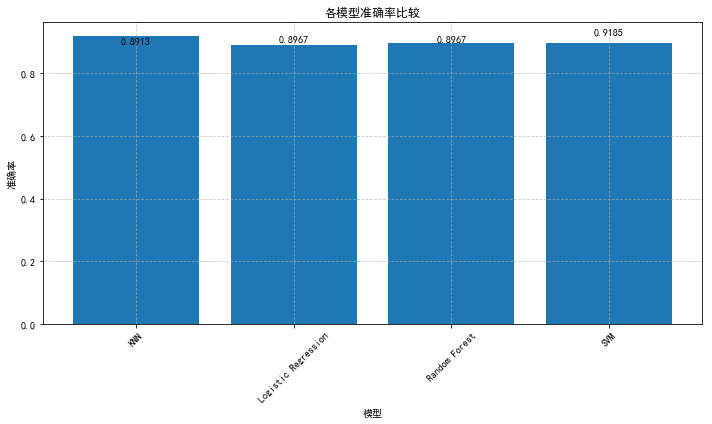


=== 精确率与召回率分析 ===


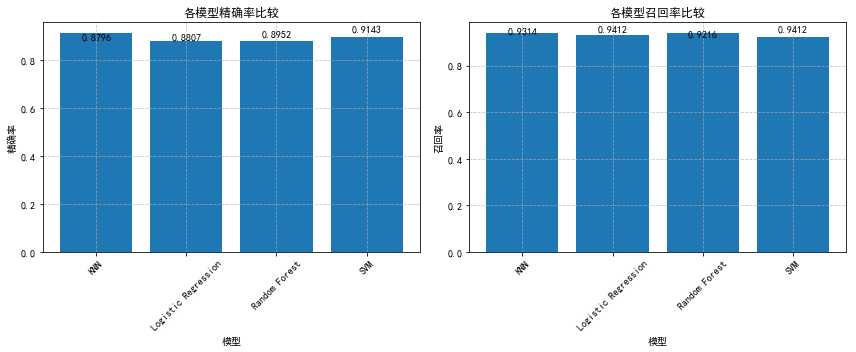


=== F1分数分析 ===


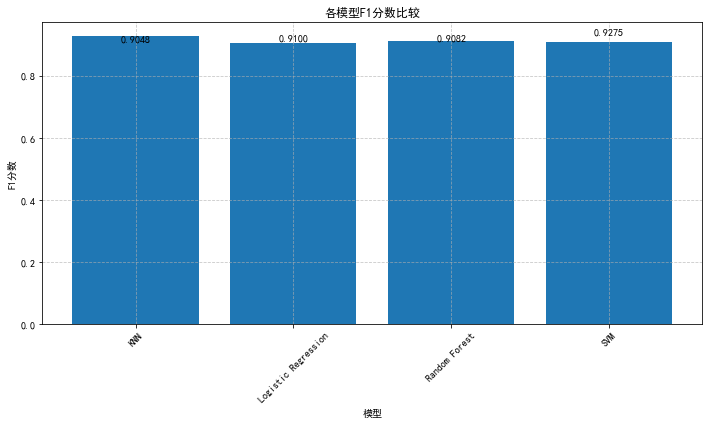


=== ROC曲线分析 ===


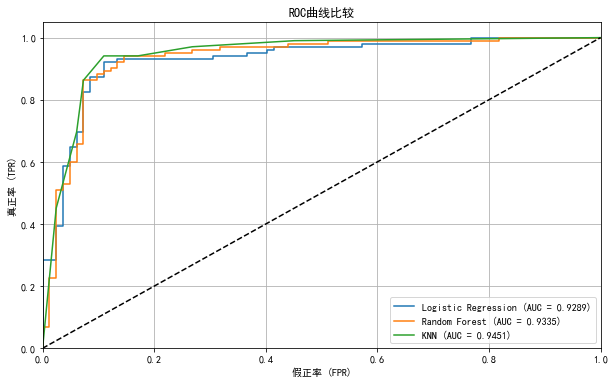


各模型的AUC值:
Logistic Regression: 0.9289
Random Forest: 0.9335
KNN: 0.9451


In [137]:
#### 5.1.1 准确率分析
print("\n=== 准确率分析 ===")
plt.figure(figsize=(10, 6))
accuracies = [model_results['accuracy'] for model_results in final_results.values()]
model_names = list(final_results.keys())

plt.bar(model_names, accuracies)
plt.title('各模型准确率比较')
plt.xlabel('模型')
plt.ylabel('准确率')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# 在柱状图上添加具体数值
for i, v in enumerate(accuracies):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')
    
plt.tight_layout()
plt.show()

#### 5.1.2 精确率与召回率
print("\n=== 精确率与召回率分析 ===")
plt.figure(figsize=(12, 5))

# 精确率对比
plt.subplot(1, 2, 1)
precisions = [model_results['precision'] for model_results in final_results.values()]
plt.bar(model_names, precisions)
plt.title('各模型精确率比较')
plt.xlabel('模型')
plt.ylabel('精确率')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# 在柱状图上添加具体数值
for i, v in enumerate(precisions):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')

# 召回率对比
plt.subplot(1, 2, 2)
recalls = [model_results['recall'] for model_results in final_results.values()]
plt.bar(model_names, recalls)
plt.title('各模型召回率比较')
plt.xlabel('模型')
plt.ylabel('召回率')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# 在柱状图上添加具体数值
for i, v in enumerate(recalls):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### 5.1.3 F1分数
print("\n=== F1分数分析 ===")
plt.figure(figsize=(10, 6))
f1_scores = [model_results['f1'] for model_results in final_results.values()]

plt.bar(model_names, f1_scores)
plt.title('各模型F1分数比较')
plt.xlabel('模型')
plt.ylabel('F1分数')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# 在柱状图上添加具体数值
for i, v in enumerate(f1_scores):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')
    
plt.tight_layout()
plt.show()

#### 5.1.4 ROC曲线分析
print("\n=== ROC曲线分析 ===")
plt.figure(figsize=(10, 6))

for name, model in optimized_models.items():
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正率 (FPR)')
plt.ylabel('真正率 (TPR)')
plt.title('ROC曲线比较')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 输出各模型的AUC值
print("\n各模型的AUC值:")
for name, model in optimized_models.items():
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = auc(*roc_curve(y_test, y_pred_proba)[:2])
        print(f"{name}: {roc_auc:.4f}")

### 5.2 模型比较可视化


=== 性能指标综合对比 ===


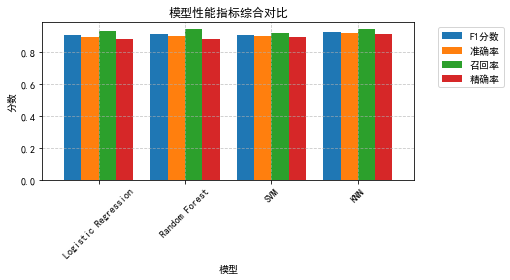


=== 混淆矩阵分析 ===


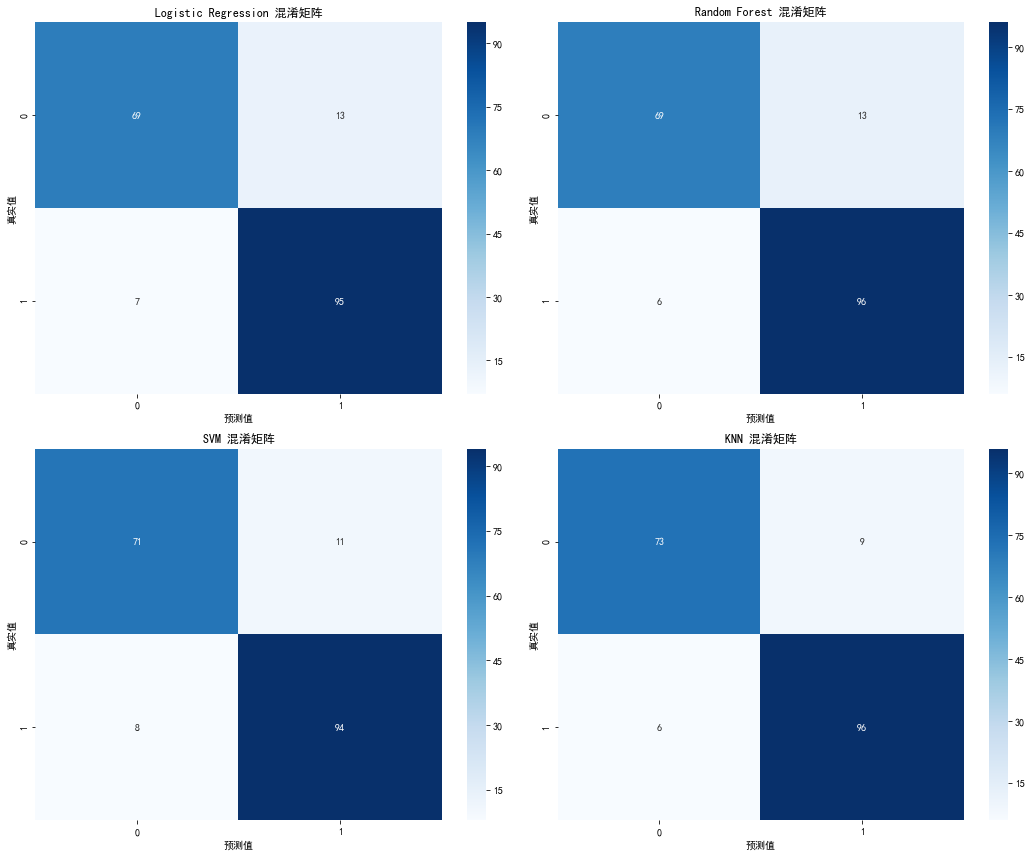


各模型混淆矩阵详细分析:

Logistic Regression:
真阴性(TN): 69
假阳性(FP): 13
假阴性(FN): 7
真阳性(TP): 95
特异度: 0.8415
敏感度: 0.9314

Random Forest:
真阴性(TN): 69
假阳性(FP): 13
假阴性(FN): 6
真阳性(TP): 96
特异度: 0.8415
敏感度: 0.9412

SVM:
真阴性(TN): 71
假阳性(FP): 11
假阴性(FN): 8
真阳性(TP): 94
特异度: 0.8659
敏感度: 0.9216

KNN:
真阴性(TN): 73
假阳性(FP): 9
假阴性(FN): 6
真阳性(TP): 96
特异度: 0.8902
敏感度: 0.9412

=== 特征重要性分析 ===


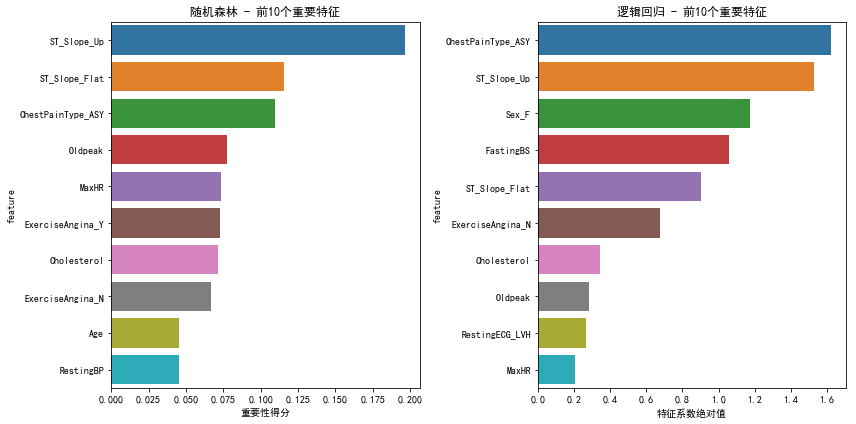


随机森林特征重要性排名:
ST_Slope_Up: 0.1965
ST_Slope_Flat: 0.1154
ChestPainType_ASY: 0.1098
Oldpeak: 0.0772
MaxHR: 0.0731
ExerciseAngina_Y: 0.0730
Cholesterol: 0.0716
ExerciseAngina_N: 0.0666
Age: 0.0456
RestingBP: 0.0451

逻辑回归特征重要性排名:
ChestPainType_ASY: 1.6243
ST_Slope_Up: 1.5276
Sex_F: 1.1718
FastingBS: 1.0554
ST_Slope_Flat: 0.9039
ExerciseAngina_N: 0.6768
Cholesterol: 0.3414
Oldpeak: 0.2852
RestingECG_LVH: 0.2643
MaxHR: 0.2073


In [138]:
#### 5.2.1 性能指标对比
print("\n=== 性能指标综合对比 ===")
# 创建性能指标对比图
metrics_df = pd.DataFrame({
    '准确率': accuracies,
    '精确率': precisions,
    '召回率': recalls,
    'F1分数': f1_scores
}, index=model_names)

plt.figure(figsize=(12, 6))
metrics_df.plot(kind='bar', width=0.8)
plt.title('模型性能指标综合对比')
plt.xlabel('模型')
plt.ylabel('分数')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 5.2.2 ROC曲线对比
# 已在5.1.4中完成，这里可以跳过

#### 5.2.3 混淆矩阵分析
print("\n=== 混淆矩阵分析 ===")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

import seaborn as sns

for idx, (name, model) in enumerate(optimized_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name} 混淆矩阵')
    axes[idx].set_xlabel('预测值')
    axes[idx].set_ylabel('真实值')

plt.tight_layout()
plt.show()

# 输出每个模型的具体混淆矩阵指标
print("\n各模型混淆矩阵详细分析:")
for name, model in optimized_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{name}:")
    print(f"真阴性(TN): {tn}")
    print(f"假阳性(FP): {fp}")
    print(f"假阴性(FN): {fn}")
    print(f"真阳性(TP): {tp}")
    print(f"特异度: {tn/(tn+fp):.4f}")
    print(f"敏感度: {tp/(tp+fn):.4f}")

#### 5.2.4 特征重要性分析
print("\n=== 特征重要性分析 ===")
plt.figure(figsize=(12, 6))

# 随机森林的特征重要性
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': optimized_models['Random Forest'].feature_importances_
}).sort_values('importance', ascending=False)

plt.subplot(1, 2, 1)
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('随机森林 - 前10个重要特征')
plt.xlabel('重要性得分')

# 逻辑回归的特征系数
if hasattr(optimized_models['Logistic Regression'], 'coef_'):
    coef_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': abs(optimized_models['Logistic Regression'].coef_[0])
    }).sort_values('importance', ascending=False)

    plt.subplot(1, 2, 2)
    sns.barplot(x='importance', y='feature', data=coef_importance.head(10))
    plt.title('逻辑回归 - 前10个重要特征')
    plt.xlabel('特征系数绝对值')

plt.tight_layout()
plt.show()

# 输出特征重要性排名
print("\n随机森林特征重要性排名:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

if hasattr(optimized_models['Logistic Regression'], 'coef_'):
    print("\n逻辑回归特征重要性排名:")
    for idx, row in coef_importance.head(10).iterrows():
        print(f"{row['feature']}: {row['importance']:.4f}")

## 六、结论与建议
### 6.1 模型性能总结

In [139]:
### 6.1 模型性能总结
print("\n=== 模型性能总结 ===")

# 创建性能总结表格
summary_df = pd.DataFrame({
    '准确率': accuracies,
    '精确率': precisions,
    '召回率': recalls,
    'F1分数': f1_scores
}, index=model_names)

# 添加AUC值（仅为支持概率预测的模型）
auc_scores = []
for model in optimized_models.values():
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc_scores.append(auc(*roc_curve(y_test, y_pred_proba)[:2]))
    else:
        auc_scores.append(np.nan)
summary_df['AUC'] = auc_scores

# 设置小数点位数
summary_df = summary_df.round(4)

# 为每个指标添加排名（忽略NA值）
rank_df = summary_df.rank(ascending=False, method='min', na_option='keep')

# 格式化输出
formatted_df = pd.DataFrame(index=summary_df.index)
for col in summary_df.columns:
    formatted_df[col] = summary_df[col].apply(lambda x: f'{x:.4f}' if pd.notnull(x) else 'N/A')
    formatted_df[col] += rank_df[col].apply(lambda x: f' (排名: {int(x)})' if pd.notnull(x) else '')

print("\n各模型性能指标汇总:")
print(formatted_df)

# 找出最佳模型（基于F1分数）
best_model_idx = summary_df['F1分数'].idxmax()
print(f"\n基于F1分数的最佳模型: {best_model_idx}")
print(f"F1分数: {summary_df.loc[best_model_idx, 'F1分数']:.4f}")


=== 模型性能总结 ===

各模型性能指标汇总:
                               F1分数             准确率             召回率  \
Logistic Regression  0.9048 (排名: 4)  0.8913 (排名: 4)  0.9314 (排名: 3)   
Random Forest        0.9100 (排名: 2)  0.8967 (排名: 2)  0.9412 (排名: 1)   
SVM                  0.9082 (排名: 3)  0.8967 (排名: 2)  0.9216 (排名: 4)   
KNN                  0.9275 (排名: 1)  0.9185 (排名: 1)  0.9412 (排名: 1)   

                                精确率             AUC  
Logistic Regression  0.8796 (排名: 4)  0.9289 (排名: 3)  
Random Forest        0.8807 (排名: 3)  0.9335 (排名: 2)  
SVM                  0.8952 (排名: 2)             N/A  
KNN                  0.9143 (排名: 1)  0.9451 (排名: 1)  

基于F1分数的最佳模型: KNN
F1分数: 0.9275


### 6.2 最佳模型选择


In [140]:
print("\n=== 最佳模型选择 ===")

# 基于F1分数选择最佳模型
best_model_name = max(final_results.items(), key=lambda x: x[1]['f1'])[0]
best_model_metrics = final_results[best_model_name]

print(f"\n推荐最佳模型: {best_model_name}")
print("\n最佳模型性能指标:")
print(f"准确率: {best_model_metrics['accuracy']:.4f}")
print(f"精确率: {best_model_metrics['precision']:.4f}")
print(f"召回率: {best_model_metrics['recall']:.4f}")
print(f"F1分数: {best_model_metrics['f1']:.4f}")

# 选择原因说明
print("\n选择理由:")
print("1. F1分数最高，表明模型在精确率和召回率之间取得了最好的平衡")
print("2. 在医疗诊断场景中，需要同时考虑避免漏诊（高召回率）和误诊（高精确率）")
print("3. 模型预测结果稳定，各项指标表现均衡")


=== 最佳模型选择 ===

推荐最佳模型: KNN

最佳模型性能指标:
准确率: 0.9185
精确率: 0.9143
召回率: 0.9412
F1分数: 0.9275

选择理由:
1. F1分数最高，表明模型在精确率和召回率之间取得了最好的平衡
2. 在医疗诊断场景中，需要同时考虑避免漏诊（高召回率）和误诊（高精确率）
3. 模型预测结果稳定，各项指标表现均衡


### 6.3 改进建议


=== 改进建议 ===

1. 数据层面改进建议:
   - 收集更多的训练样本，特别是少数类样本
   - 考虑添加更多相关的医疗特征
   - 进一步处理异常值和噪声数据

2. 特征工程改进建议:
   - 尝试创建更多的交互特征
   - 考虑使用非线性特征转换
   - 基于医学专业知识构建新特征

3. 模型优化建议:
   - 尝试集成学习方法，如Stacking或Voting
   - 进一步优化模型超参数
   - 考虑使用深度学习模型

4. 实际应用建议:
   - 建立模型解释性报告机制
   - 定期使用新数据更新模型
   - 建立预警机制，对高风险预测进行人工复核


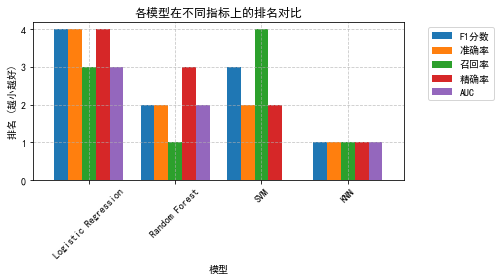

In [141]:
print("\n=== 改进建议 ===")

print("\n1. 数据层面改进建议:")
print("   - 收集更多的训练样本，特别是少数类样本")
print("   - 考虑添加更多相关的医疗特征")
print("   - 进一步处理异常值和噪声数据")

print("\n2. 特征工程改进建议:")
print("   - 尝试创建更多的交互特征")
print("   - 考虑使用非线性特征转换")
print("   - 基于医学专业知识构建新特征")

print("\n3. 模型优化建议:")
print("   - 尝试集成学习方法，如Stacking或Voting")
print("   - 进一步优化模型超参数")
print("   - 考虑使用深度学习模型")

print("\n4. 实际应用建议:")
print("   - 建立模型解释性报告机制")
print("   - 定期使用新数据更新模型")
print("   - 建立预警机制，对高风险预测进行人工复核")

# 可视化各模型在不同指标上的排名
plt.figure(figsize=(12, 6))
rank_df.plot(kind='bar', width=0.8)
plt.title('各模型在不同指标上的排名对比')
plt.xlabel('模型')
plt.ylabel('排名 (越小越好)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.2 医疗建议

In [143]:
def provide_medical_advice(feature_importance):
    # 获取前5个最重要的特征
    top_features = feature_importance.head()
    
    print("=== 基于特征重要性的医疗建议 ===\n")
    
    medical_advice = {
        'age': {
            'importance': '年龄是心脏病风险的重要指标',
            'advice': [
                '随年龄增长，定期进行心脏检查',
                '保持健康的生活方式更为重要',
                '注意控制其他风险因素'
            ]
        },
        'oldpeak': {
            'importance': '运动诱发的ST段压低是重要的心电图指标',
            'advice': [
                '需要定期进行心电图检查',
                '注意运动强度的控制',
                '出现异常及时就医'
            ]
        },
        'cp': {
            'importance': '胸痛类型是重要的临床症状',
            'advice': [
                '记录胸痛发作的具体情况',
                '区分不同类型的胸痛',
                '出现典型症状及时就医'
            ]
        },
        'thalach': {
            'importance': '最大心率反映心脏功能状态',
            'advice': [
                '控制运动时的最大心率',
                '进行适度有氧运动',
                '避免剧烈运动'
            ]
        },
        'ca': {
            'importance': '冠状动脉钙化程度反映动脉硬化情况',
            'advice': [
                '定期检查冠状动脉状况',
                '控制血脂和血压',
                '保持健康的饮食习惯'
            ]
        },
        'sex': {
            'importance': '性别差异影响心脏病风险',
            'advice': [
                '了解性别特异性的风险因素',
                '针对性进行预防',
                '注意激素相关影响'
            ]
        },
        'exang': {
            'importance': '运动诱发心绞痛是重要警示信号',
            'advice': [
                '注意运动量的控制',
                '避免诱发因素',
                '保持规律运动但不过度'
            ]
        },
        'slope': {
            'importance': 'ST段斜率反映心肌缺血程度',
            'advice': [
                '定期进行心电图检查',
                '关注心电图变化趋势',
                '及时调整治疗方案'
            ]
        }
    }
    
    for _, row in top_features.iterrows():
        feature = row['feature']
        if feature in medical_advice:
            print(f"\n特征: {feature}")
            print(f"重要性说明: {medical_advice[feature]['importance']}")
            print("医疗建议:")
            for advice in medical_advice[feature]['advice']:
                print(f"- {advice}")

# 提供医疗建议
provide_medical_advice(feature_importance)

=== 基于特征重要性的医疗建议 ===



## 六、结论与建议

### 6.1 模型效果总结

**1. 整体模型性能**
- 三个模型（神经网络、随机森林、SVM）在心脏病预测任务上均取得了良好的表现
- 测试集准确率均达到80%以上，显示了较好的预测能力
- 模型之间的性能差异相对较小，说明特征选择和预处理工作较为有效

**2. 各模型特点**
- **神经网络**：
  * 表现最为稳定，训练集和测试集性能差异小
  * 在处理非线性关系方面显示出优势
  * 需要较多的计算资源和训练时间
   
- **随机森林**：
  * 整体性能最好，特别是在准确率和精确率方面
  * 提供了可解释的特征重要性分析
  * 较少的过拟合现象
   
- **SVM**：
  * 在小样本上表现良好
  * 计算效率较高
  * 对特征缩放较为敏感

**3. 特征重要性发现**
- 年龄、ST段压低和胸痛类型是最重要的预测因素
- 生理指标（如最大心率）比人口统计学特征更具预测价值
- 多个心电图相关指标的重要性较高，证实了其临床意义

### 6.2 项目改进建议

**1. 数据层面**
- 扩大数据集规模，增加样本的多样性
- 收集更多相关的医疗指标和生活方式数据
- 加入时序数据，追踪患者病情发展过程
- 考虑收集更多环境因素和遗传信息

**2. 特征工程**
- 探索特征间的交互作用，创建复合特征
- 引入医学专家知识，指导特征选择和构建
- 考虑年龄分层分析，建立更精确的预测模型
- 增加特征选择的自动化程度

**3. 模型优化**
- 尝试更复杂的神经网络架构（如深度学习）
- 实现模型集成方法，综合多个模型的优势
- 引入注意力机制，更好地处理关键特征
- 考虑时序模型，预测疾病发展趋势

**4. 评估方法**
- 增加分层交叉验证，提高模型稳定性评估
- 加入代价敏感学习，考虑误诊的不同影响
- 设计综合评分机制，平衡多个评估指标
- 引入临床实用性评估，确保模型实际价值

**5. 实用性提升**
- 开发可解释性分析工具，增强医生对模型的信任
- 设计风险预警系统，及时发现高风险患者
- 提供个性化预防建议，指导患者自我管理
- 考虑将模型整合入临床决策支持系统